# Hartmann 6D: offline branch-and-select min_samples_leaf policy

This notebook visualizes the offline branch-and-select experiment and compares the discovered blockwise min_samples_leaf policy against fixed-min_samples_leaf SMAC runs.

Expected result folders:

- `hartmann_6d_branch_select_min_samples_leaf/`
- `hartmann_6d_fixed_vs_learned_min_samples_leaf/`

In [43]:
from __future__ import annotations

import json
from pathlib import Path
from typing import Iterable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import t

from master_utils.reload_components import load_smac_components
from smac import Scenario
from smac.runhistory.runhistory import RunHistory

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

In [44]:
MIN_SAMPLES_LEAF_VALUES = [1, 2, 3, 4, 5]
SEEDS = range(5)
TRIALS_PER_BLOCK = 100
N_BLOCKS = 5
N_TRIALS = TRIALS_PER_BLOCK * N_BLOCKS
HARTMANN_6D_OPTIMUM = -3.322368011
REGRET_EPSILON = 1e-300

POLICIES = [f"leaf_{leaf}" for leaf in MIN_SAMPLES_LEAF_VALUES] + ["learned_branch_select_policy"]

ROOT = Path("/home/io632776/experiments/adaptive-smac/experiments/hartmann/05_force_variable_min_samples_leaf")
BRANCH_SELECT_DIRECTORY = ROOT / "hartmann_6d_branch_select_min_samples_leaf"
COMPARISON_DIRECTORY = ROOT / "hartmann_6d_fixed_vs_learned_min_samples_leaf"
FIGURE_DIRECTORY = ROOT / "figures"
FIGURE_DIRECTORY.mkdir(parents=True, exist_ok=True)

print("branch-select dir:", BRANCH_SELECT_DIRECTORY)
print("comparison dir:", COMPARISON_DIRECTORY)

branch-select dir: /home/io632776/experiments/adaptive-smac/experiments/hartmann/05_force_variable_min_samples_leaf/hartmann_6d_branch_select_min_samples_leaf
comparison dir: /home/io632776/experiments/adaptive-smac/experiments/hartmann/05_force_variable_min_samples_leaf/hartmann_6d_fixed_vs_learned_min_samples_leaf


## Helper functions

In [45]:
def runhistory_costs_in_order(runhistory: RunHistory) -> np.ndarray:
    ordered_trials = sorted(
        runhistory.items(),
        key=lambda item: (item[1].starttime, item[1].endtime),
    )
    return np.asarray([float(value.cost) for _, value in ordered_trials], dtype=float)


def best_so_far(costs: Iterable[float]) -> np.ndarray:
    return np.minimum.accumulate(np.asarray(list(costs), dtype=float))


def log10_simple_regret(best_costs: Iterable[float]) -> np.ndarray:
    regret = np.asarray(list(best_costs), dtype=float) - HARTMANN_6D_OPTIMUM
    return np.log10(np.clip(regret, REGRET_EPSILON, None))


def log2_simple_regret(best_costs: Iterable[float]) -> np.ndarray:
    regret = np.asarray(list(best_costs), dtype=float) - HARTMANN_6D_OPTIMUM
    return np.log2(np.clip(regret, REGRET_EPSILON, None))


def load_runhistory(run_dir: Path) -> RunHistory:
    components = load_smac_components(run_dir, facade="hpo")
    return components["runhistory"]


def load_selected_runhistory(seed: int) -> RunHistory:
    seed_dir = BRANCH_SELECT_DIRECTORY / f"seed_{seed}"
    with open(seed_dir / "summary.json") as fh:
        summary = json.load(fh)

    branch_dir = Path(summary["blocks"][0]["branches"][0]["branch_dir"])
    scenario = Scenario.load(branch_dir)

    runhistory = RunHistory()
    runhistory.load(seed_dir / "selected_runhistory.json", configspace=scenario.configspace)
    return runhistory


def mean_ci(values: np.ndarray, confidence: float = 0.95) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    mean = np.nanmean(values, axis=0)
    n = np.sum(~np.isnan(values), axis=0)
    std = np.nanstd(values, axis=0, ddof=1)
    stderr = std / np.sqrt(n)
    critical = t.ppf((1 + confidence) / 2, n - 1)
    half_width = critical * stderr
    half_width = np.where(n > 1, half_width, 0.0)
    return mean, mean - half_width, mean + half_width

## Available branch-select summaries

In [46]:
summary_rows = []
for seed in SEEDS:
    summary_path = BRANCH_SELECT_DIRECTORY / f"seed_{seed}" / "summary.json"
    if not summary_path.exists():
        continue

    with open(summary_path) as fh:
        summary = json.load(fh)

    summary_rows.append(
        {
            "seed": seed,
            "selected_leaf_values": " -> ".join(str(leaf) for leaf in summary["selected_leaf_values"]),
            "selected_trials": summary["selected_trials"],
            "actual_evaluations": summary["actual_evaluations"],
            "final_incumbent_cost": summary["final_incumbent_cost"],
        }
    )

summary_df = pd.DataFrame(summary_rows)
summary_df

,seed,selected_leaf_values,selected_trials,actual_evaluations,final_incumbent_cost
0,0,4 -> 2 -> 3 -> 3 -> 1,500,2500,-3.203118
1,1,2 -> 2 -> 2 -> 2 -> 1,500,2500,-3.202633
2,2,4 -> 4 -> 2 -> 1 -> 1,500,2500,-3.321876
3,3,1 -> 4 -> 1 -> 2 -> 4,500,2500,-3.201390
4,4,5 -> 4 -> 4 -> 1 -> 4,500,2500,-3.319989


## Mean selected min_samples_leaf across seeds

This plot summarizes the discovered policy by averaging the selected min_samples_leaf value for each 100-trial block across all available seeds. The gray lines show the individual seed policies.

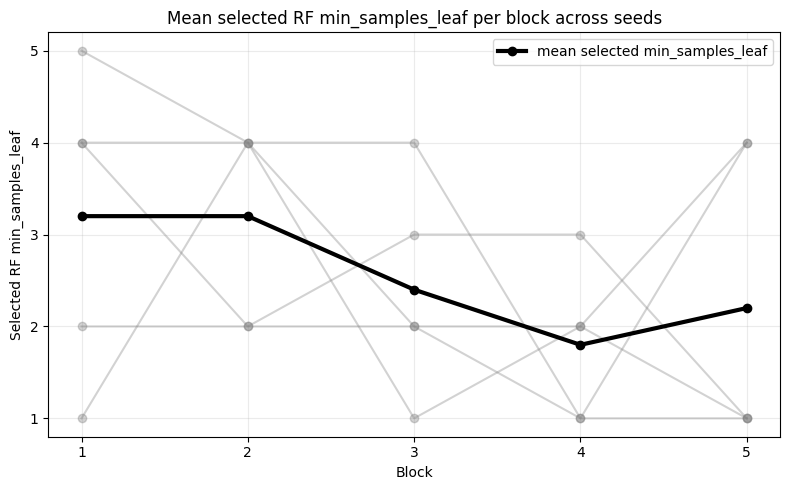

block,1,2,3,4,5
seed,,,,,
0,4,2,3,3,1
1,2,2,2,2,1
2,4,4,2,1,1
3,1,4,1,2,4
4,5,4,4,1,4


In [47]:
selected_leaf_rows = []
for seed in SEEDS:
    summary_path = BRANCH_SELECT_DIRECTORY / f"seed_{seed}" / "summary.json"
    if not summary_path.exists():
        continue

    with open(summary_path) as fh:
        summary = json.load(fh)

    for block_idx, leaf in enumerate(summary["selected_leaf_values"], start=1):
        selected_leaf_rows.append(
            {
                "seed": seed,
                "block": block_idx,
                "selected_leaf": int(leaf),
            }
        )

selected_leaf_df = pd.DataFrame(selected_leaf_rows)
mean_selected_leaf = selected_leaf_df.groupby("block")["selected_leaf"].mean()

plt.figure(figsize=(8, 5))
for seed, seed_df in selected_leaf_df.groupby("seed"):
    plt.plot(
        seed_df["block"],
        seed_df["selected_leaf"],
        color="gray",
        alpha=0.35,
        linewidth=1.5,
        marker="o",
    )

plt.plot(
    mean_selected_leaf.index,
    mean_selected_leaf.values,
    color="black",
    linewidth=3,
    marker="o",
    label="mean selected min_samples_leaf",
)
plt.xticks(range(1, N_BLOCKS + 1))
plt.yticks(MIN_SAMPLES_LEAF_VALUES)
plt.xlabel("Block")
plt.ylabel("Selected RF min_samples_leaf")
plt.title("Mean selected RF min_samples_leaf per block across seeds")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIRECTORY / "mean_selected_leaf_per_block.png", dpi=200)
plt.show()

selected_leaf_df.pivot(index="seed", columns="block", values="selected_leaf")

## 1. Branch performance for the offline branch-and-select experiment

Each colored segment is one candidate min_samples_leaf branch inside one block. The black line is the selected trajectory assembled from the winning branch after each block.

In [48]:
def plot_branch_select(seed: int = 0) -> None:
    summary_path = BRANCH_SELECT_DIRECTORY / f"seed_{seed}" / "summary.json"
    if not summary_path.exists():
        raise FileNotFoundError(f"Missing {summary_path}. Run run_branch_select_min_samples_leaf.py first.")

    with open(summary_path) as fh:
        summary = json.load(fh)

    colors = dict(zip(MIN_SAMPLES_LEAF_VALUES, plt.cm.tab10(np.linspace(0, 1, len(MIN_SAMPLES_LEAF_VALUES)))))

    plt.figure(figsize=(12, 6))
    for block in summary["blocks"]:
        start = block["start_trial"]
        end = block["end_trial"]

        for branch in block["branches"]:
            leaf = int(branch["min_samples_leaf"])
            runhistory = load_runhistory(Path(branch["branch_dir"]))
            trajectory = best_so_far(runhistory_costs_in_order(runhistory))[:end]
            xs = np.arange(1, len(trajectory) + 1)

            label = f"min_samples_leaf {leaf}" if block["block"] == 1 else None
            plt.plot(
                xs[start - 1 : end],
                trajectory[start - 1 : end],
                color=colors[leaf],
                alpha=0.75,
                linewidth=1.8,
                label=label,
            )

        selected_leaf = int(block["selected"]["min_samples_leaf"])
        plt.axvspan(start, end, color=colors[selected_leaf], alpha=0.06)

    selected = best_so_far(runhistory_costs_in_order(load_selected_runhistory(seed)))
    plt.plot(
        np.arange(1, len(selected) + 1),
        selected,
        color="black",
        linewidth=2.8,
        label="selected trajectory",
    )

    selected_leaf_values = " -> ".join(str(leaf) for leaf in summary["selected_leaf_values"])
    plt.title(f"Offline branch-and-select branches, seed={seed}; selected leaf values: {selected_leaf_values}")
    plt.xlabel("Selected trial number")
    plt.ylabel("Best incumbent cost so far")
    plt.legend(title="Branch min_samples_leaf", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()

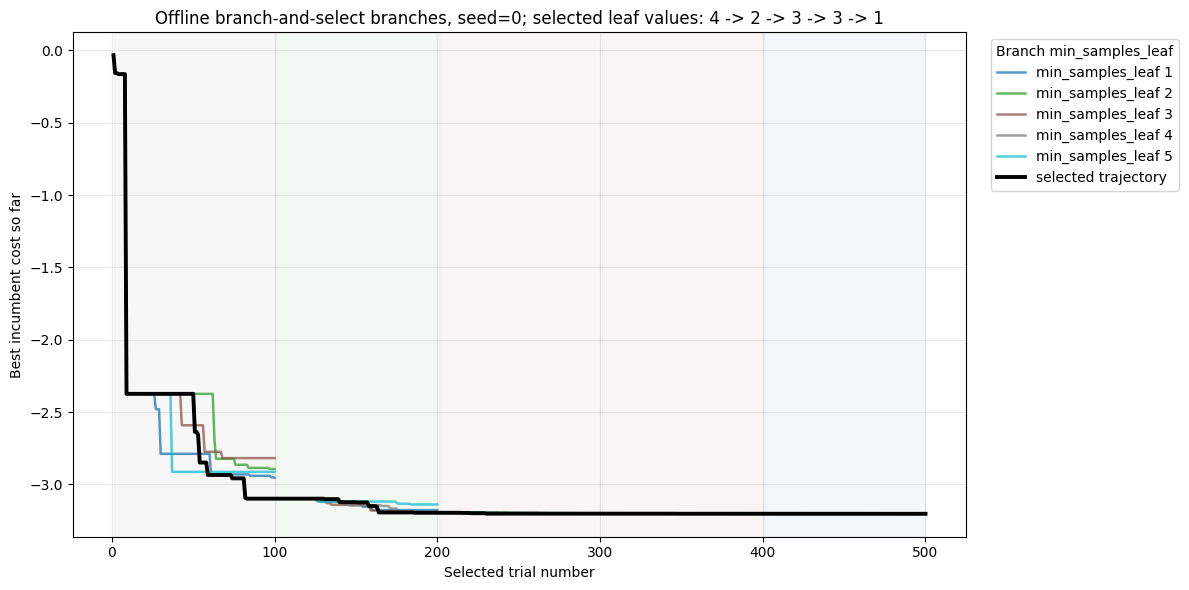

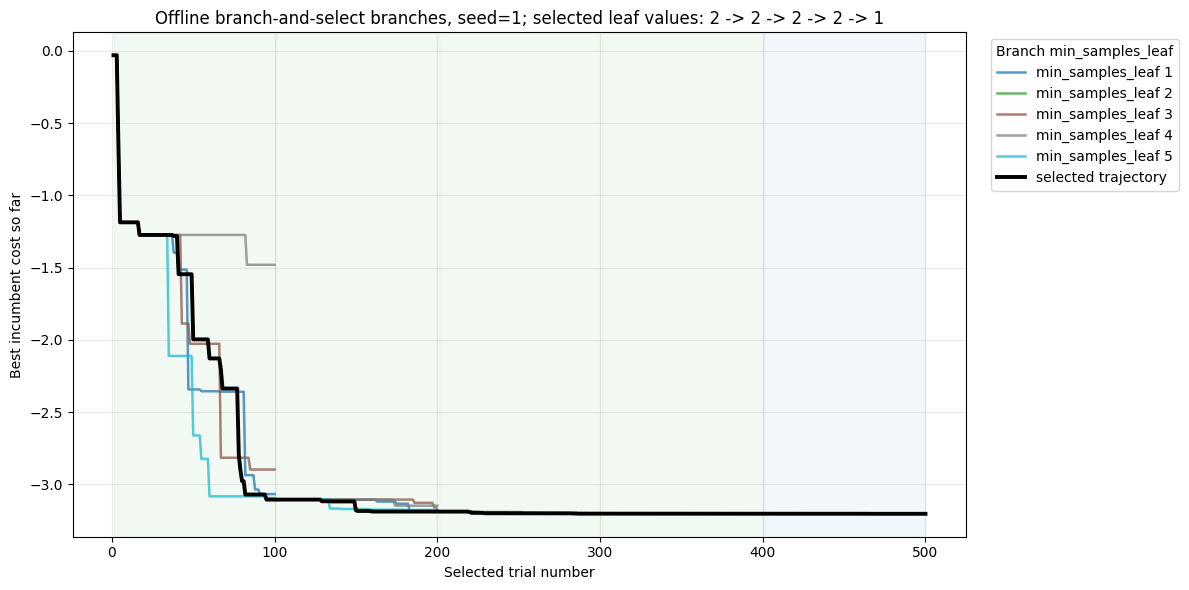

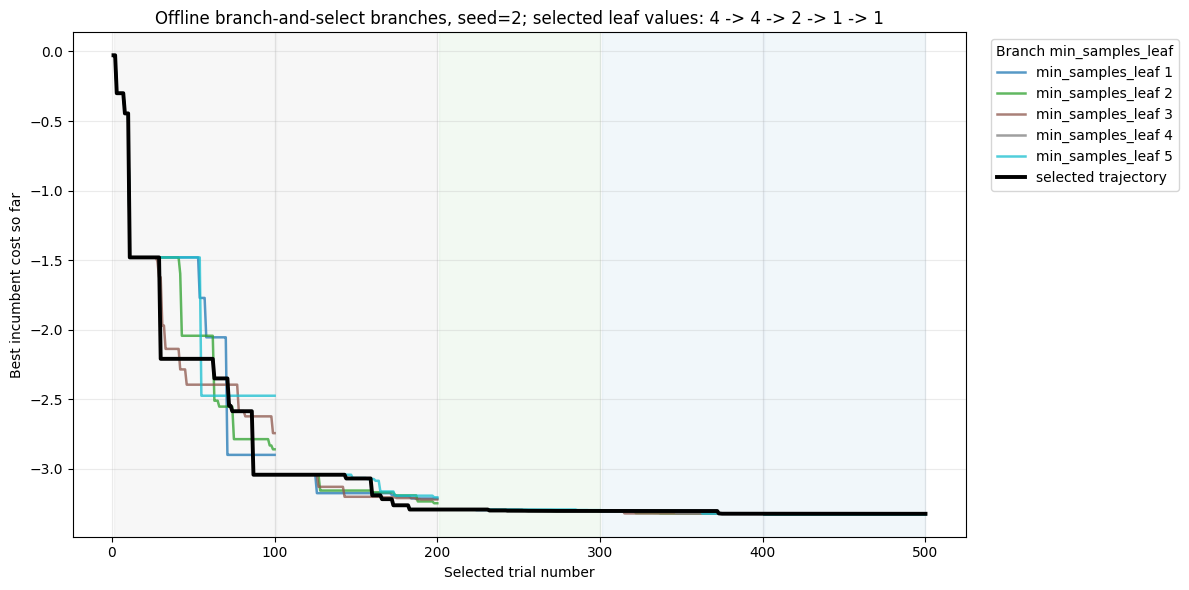

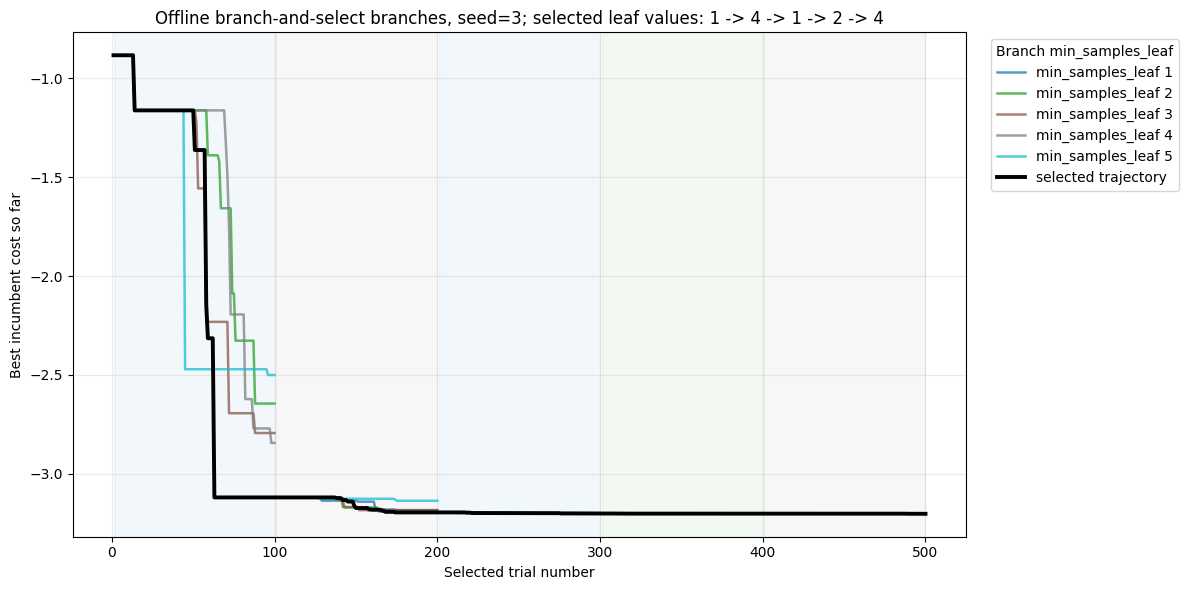

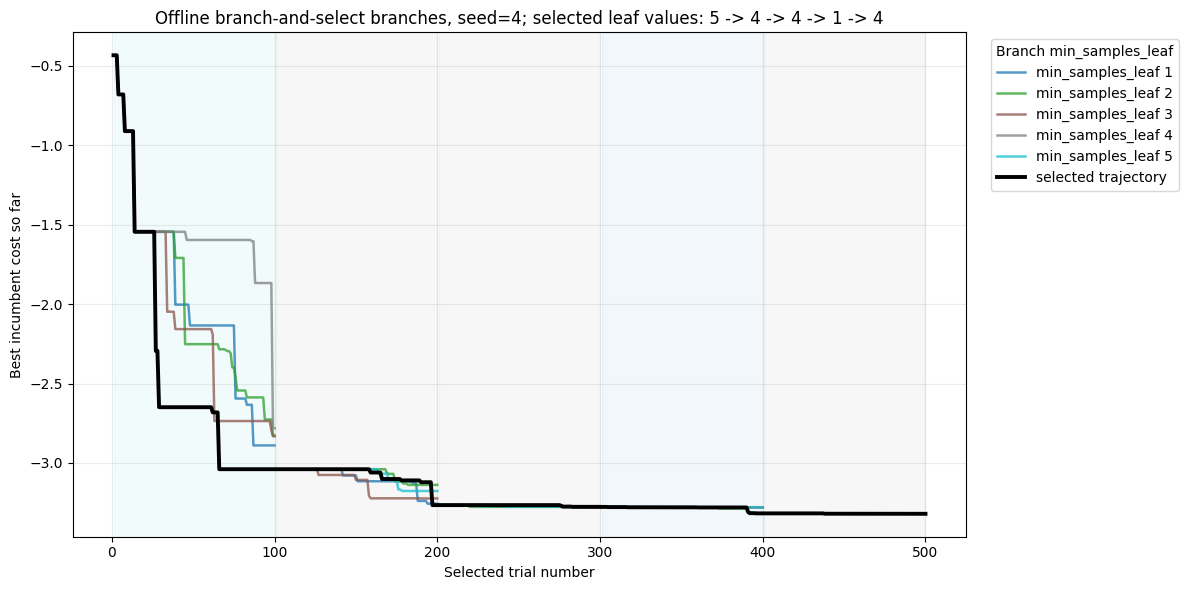

In [49]:
for seed in summary_df["seed"] if len(summary_df) else []:
    plot_branch_select(seed=int(seed))
    plt.savefig(FIGURE_DIRECTORY / f"branch_select_seed_{seed}.png", dpi=200)
    plt.show()

## 1a. Offline branches plus online rerun of the discovered policy

This is the same offline branch plot, but with the online rerun of the seed-specific discovered policy overlaid as a magenta dashed line. If the comparison file was rerun with `N_INITIAL_DESIGN_CONFIGS = 25`, the first block should be much closer to the offline selected trajectory.

In [50]:
def load_online_learned_policy_trajectory(seed: int) -> np.ndarray | None:
    run_dir = COMPARISON_DIRECTORY / "learned_branch_select_policy" / str(seed)
    if not run_dir.exists():
        return None

    runhistory = load_runhistory(run_dir)
    trajectory = best_so_far(runhistory_costs_in_order(runhistory))
    return trajectory[:N_TRIALS]


def plot_branch_select_with_online_policy(seed: int = 0) -> None:
    plot_branch_select(seed=seed)

    online = load_online_learned_policy_trajectory(seed)
    if online is None:
        print(f"No online learned-policy run found for seed={seed}.")
        return

    plt.plot(
        np.arange(1, len(online) + 1),
        online,
        color="magenta",
        linestyle="--",
        linewidth=2.8,
        label="online learned-policy rerun",
    )
    plt.legend(title="Branch / policy", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()

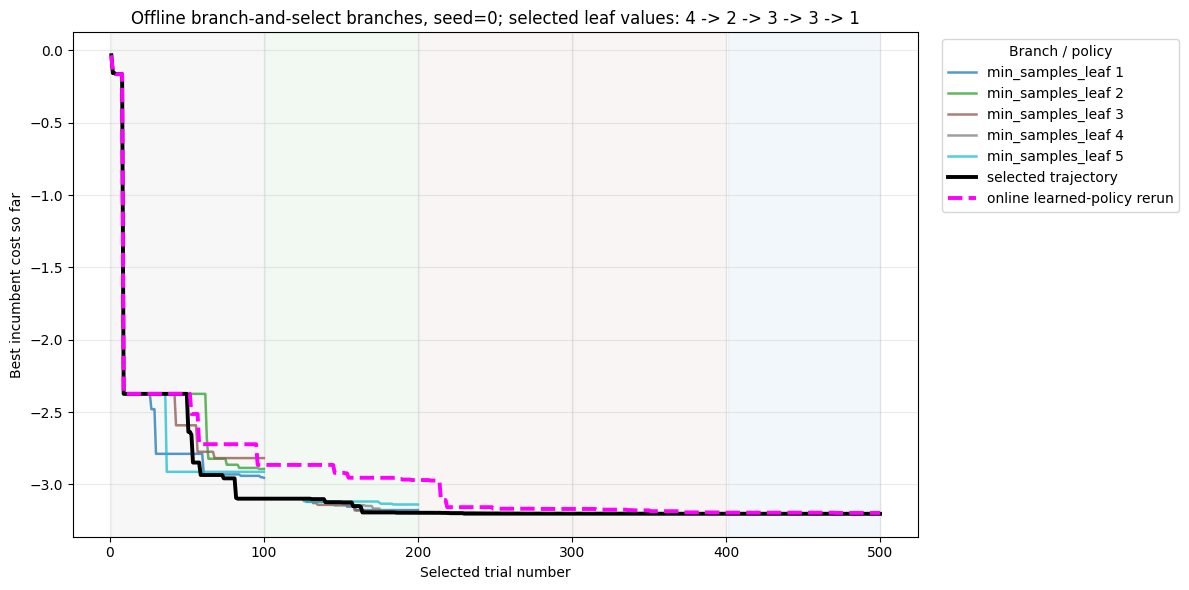

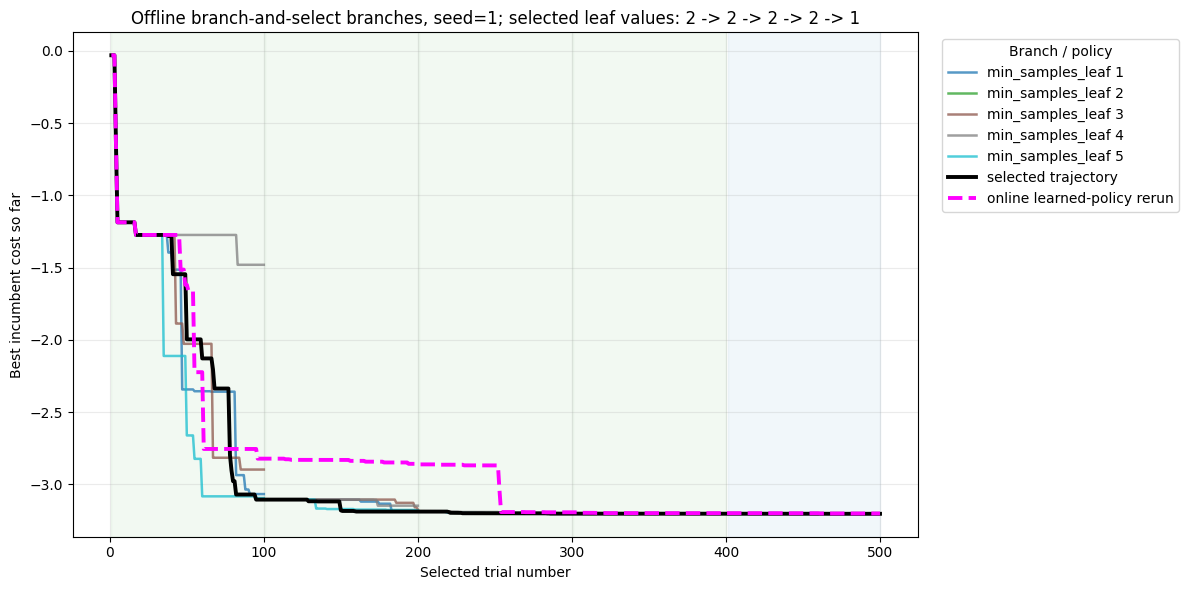

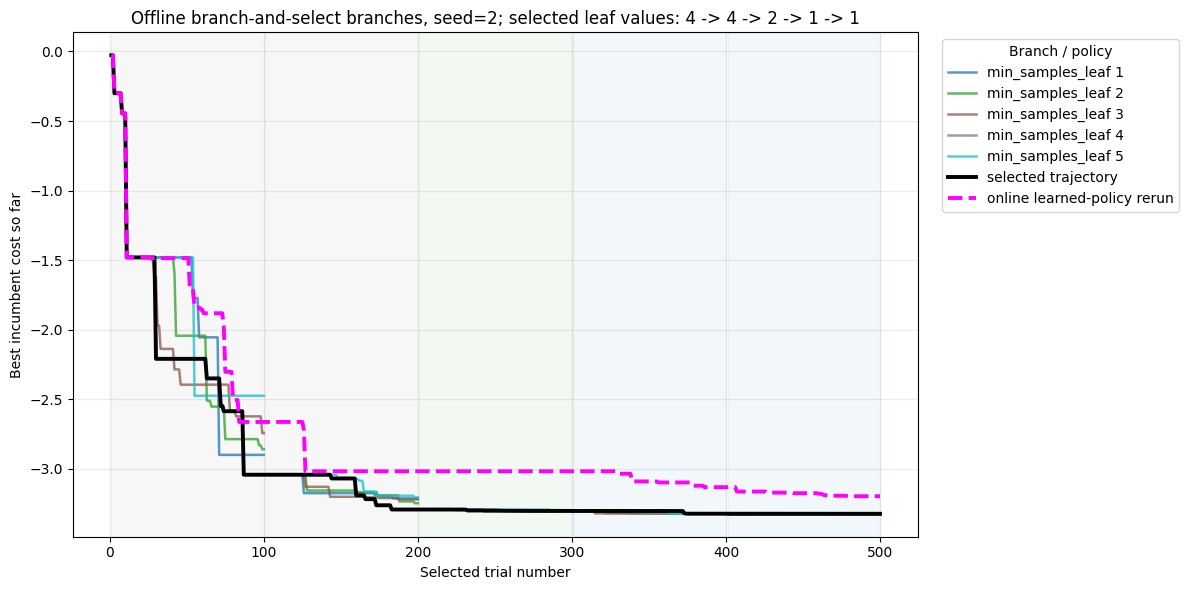

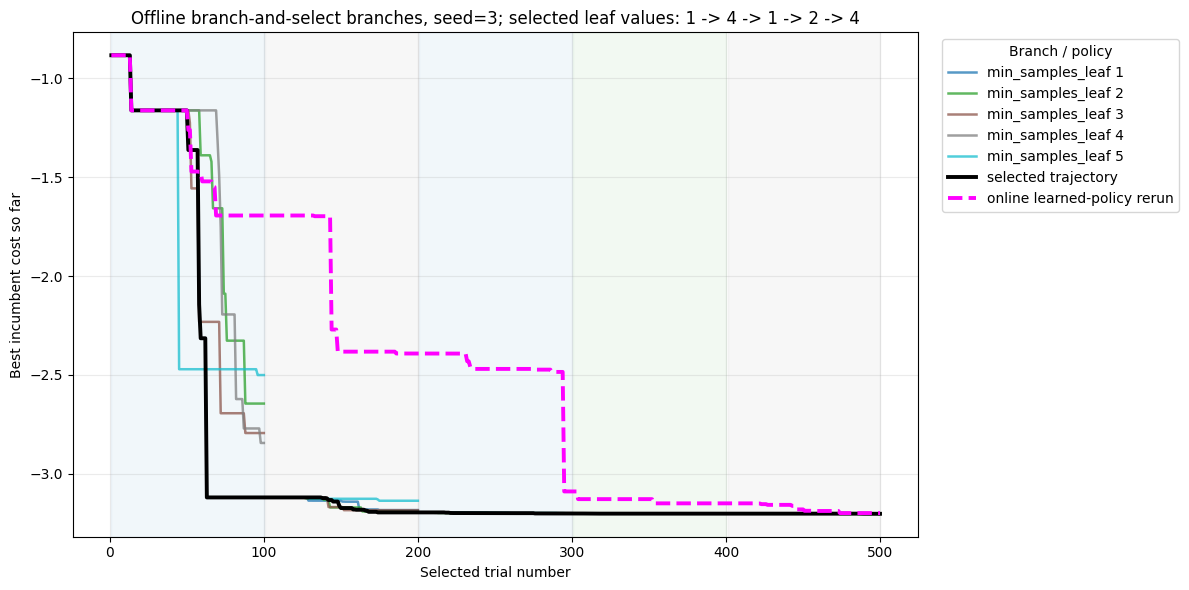

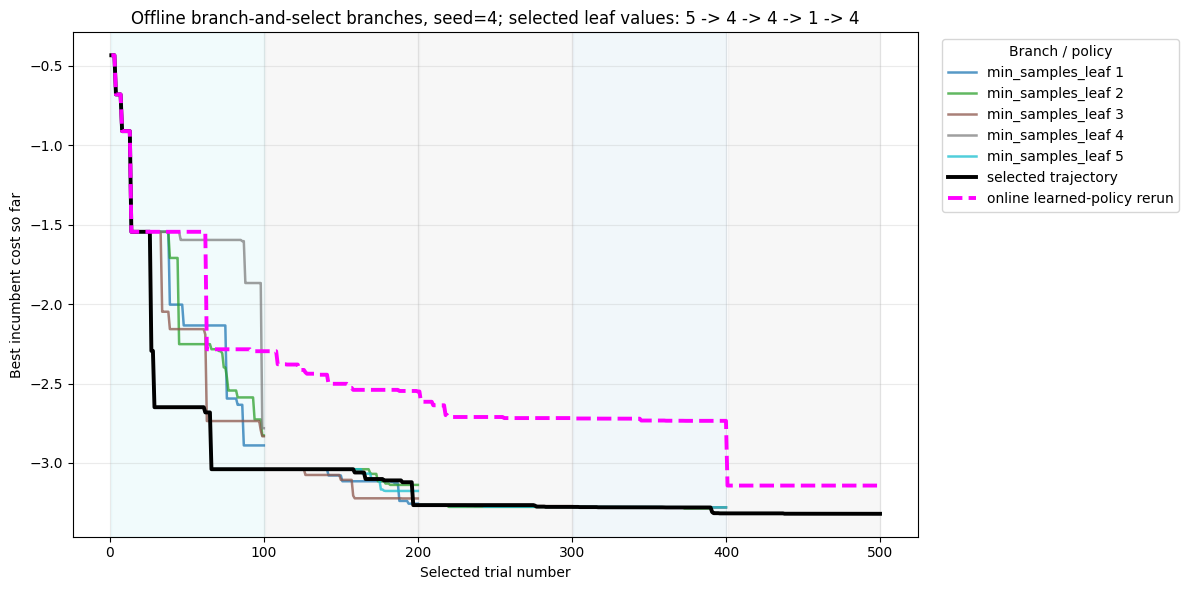

In [51]:
for seed in summary_df["seed"] if len(summary_df) else []:
    plot_branch_select_with_online_policy(seed=int(seed))
    plt.savefig(FIGURE_DIRECTORY / f"branch_select_with_online_policy_seed_{seed}.png", dpi=200)
    plt.show()

## 1a-check. Offline block 1 vs online first-block run with n=100

This checks whether an online run with only `n_trials=100` and the seed-specific first selected `min_samples_leaf` matches the offline first-block branch. Run `run_online_first_block_check.py` first; by default it creates the seed 0 check run.

In [ ]:
ONLINE_FIRST_BLOCK_DIRECTORY = ROOT / "hartmann_6d_online_first_block_check"


def offline_first_block_selected_trajectory(seed: int) -> tuple[np.ndarray, int]:
    summary_path = BRANCH_SELECT_DIRECTORY / f"seed_{seed}" / "summary.json"
    with open(summary_path) as fh:
        summary = json.load(fh)

    first_block = summary["blocks"][0]
    selected_leaf = int(first_block["selected"]["min_samples_leaf"])
    runhistory = load_runhistory(Path(first_block["selected"]["branch_dir"]))
    trajectory = best_so_far(runhistory_costs_in_order(runhistory))[:TRIALS_PER_BLOCK]
    return trajectory, selected_leaf


def online_first_block_trajectory(seed: int, selected_leaf: int) -> np.ndarray | None:
    run_dir = ONLINE_FIRST_BLOCK_DIRECTORY / f"online_first_block_leaf_{selected_leaf}" / str(seed)
    if not run_dir.exists():
        return None

    runhistory = load_runhistory(run_dir)
    return best_so_far(runhistory_costs_in_order(runhistory))[:TRIALS_PER_BLOCK]


def plot_offline_vs_online_first_block(seed: int = 0) -> None:
    offline, selected_leaf = offline_first_block_selected_trajectory(seed)
    online = online_first_block_trajectory(seed, selected_leaf)

    plt.figure(figsize=(10, 5))
    xs = np.arange(1, len(offline) + 1)
    plt.plot(xs, offline, color="black", linewidth=2.8, label="offline selected block-1 branch")

    if online is None:
        print(
            f"No online first-block run found for seed={seed}, leaf={selected_leaf}. "
            "Run run_online_first_block_check.py first."
        )
    else:
        plt.plot(
            np.arange(1, len(online) + 1),
            online,
            color="magenta",
            linestyle="--",
            linewidth=2.4,
            label="online first-block run, n=100",
        )
        first_difference = np.where(~np.isclose(offline, online, rtol=0, atol=1e-12))[0]
        if len(first_difference) == 0:
            print(f"seed={seed}: trajectories match for all {len(offline)} trials.")
        else:
            print(f"seed={seed}: first trajectory difference at trial {first_difference[0] + 1}.")

    plt.title(f"Offline block 1 vs online n=100 run, seed={seed}, min_samples_leaf={selected_leaf}")
    plt.xlabel("Trial number")
    plt.ylabel("Best incumbent cost so far")
    plt.legend()
    plt.tight_layout()

In [ ]:
plot_offline_vs_online_first_block(seed=0)
plt.savefig(FIGURE_DIRECTORY / "offline_vs_online_first_block_seed_0.png", dpi=200)
plt.show()

## 1b. Branch performance on log simple-regret scale

This shows the same branch-and-select information, but the y-axis is `log10(simple regret)`, where simple regret is `best_cost_so_far - f*` and `f* = -3.322368011` for Hartmann 6D. Lower is better.

In [52]:
def plot_branch_select_log_regret(seed: int = 0) -> None:
    summary_path = BRANCH_SELECT_DIRECTORY / f"seed_{seed}" / "summary.json"
    if not summary_path.exists():
        raise FileNotFoundError(f"Missing {summary_path}. Run run_branch_select_min_samples_leaf.py first.")

    with open(summary_path) as fh:
        summary = json.load(fh)

    colors = dict(zip(MIN_SAMPLES_LEAF_VALUES, plt.cm.tab10(np.linspace(0, 1, len(MIN_SAMPLES_LEAF_VALUES)))))

    plt.figure(figsize=(12, 6))
    for block in summary["blocks"]:
        start = block["start_trial"]
        end = block["end_trial"]

        for branch in block["branches"]:
            leaf = int(branch["min_samples_leaf"])
            runhistory = load_runhistory(Path(branch["branch_dir"]))
            best_costs = best_so_far(runhistory_costs_in_order(runhistory))[:end]
            trajectory = log10_simple_regret(best_costs)
            xs = np.arange(1, len(trajectory) + 1)

            label = f"min_samples_leaf {leaf}" if block["block"] == 1 else None
            plt.plot(
                xs[start - 1 : end],
                trajectory[start - 1 : end],
                color=colors[leaf],
                alpha=0.75,
                linewidth=1.8,
                label=label,
            )

        selected_leaf = int(block["selected"]["min_samples_leaf"])
        plt.axvspan(start, end, color=colors[selected_leaf], alpha=0.06)

    selected_best_costs = best_so_far(runhistory_costs_in_order(load_selected_runhistory(seed)))
    selected = log10_simple_regret(selected_best_costs)
    plt.plot(
        np.arange(1, len(selected) + 1),
        selected,
        color="black",
        linewidth=2.8,
        label="selected trajectory",
    )

    selected_leaf_values = " -> ".join(str(leaf) for leaf in summary["selected_leaf_values"])
    plt.title(f"Offline branch-and-select branches, log regret, seed={seed}; selected leaf values: {selected_leaf_values}")
    plt.xlabel("Selected trial number")
    plt.ylabel("log10(simple regret)")
    plt.legend(title="Branch min_samples_leaf", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()

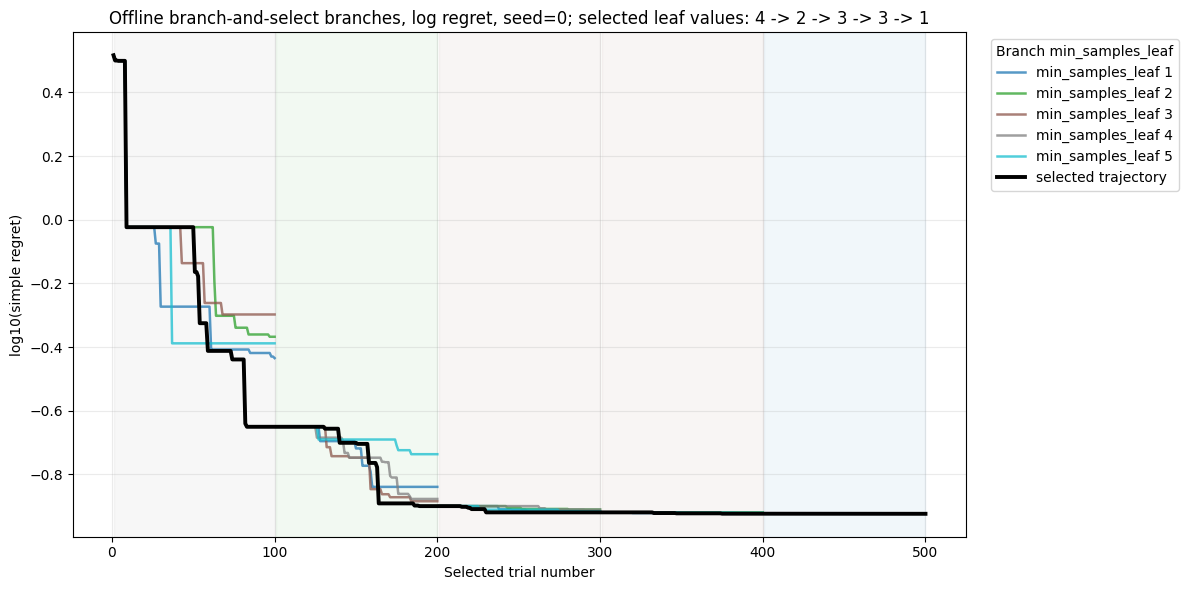

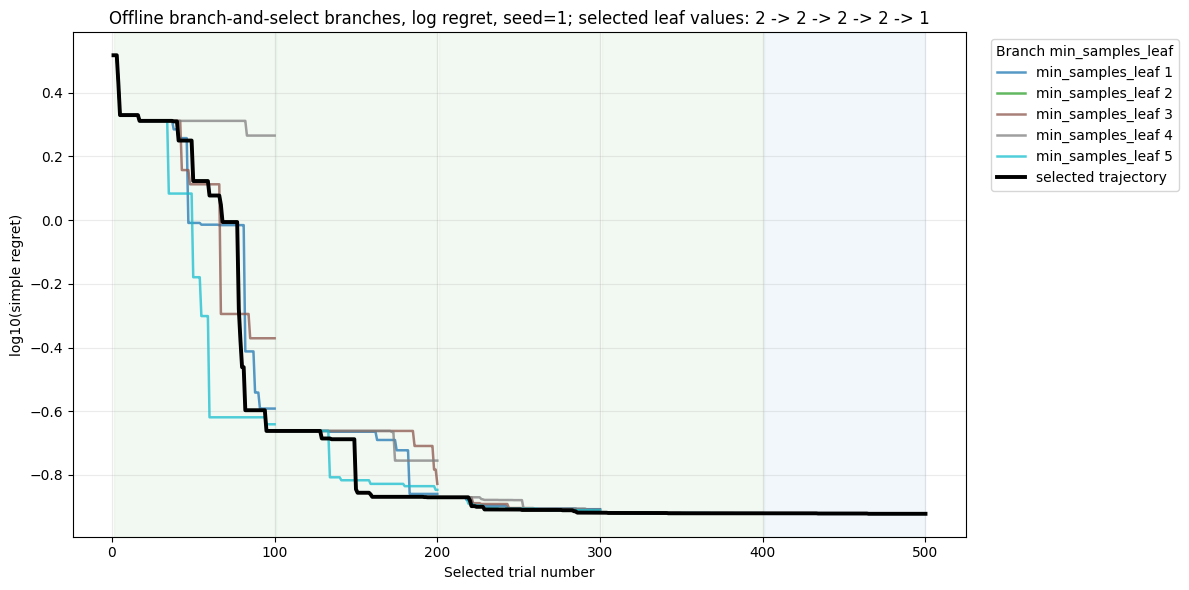

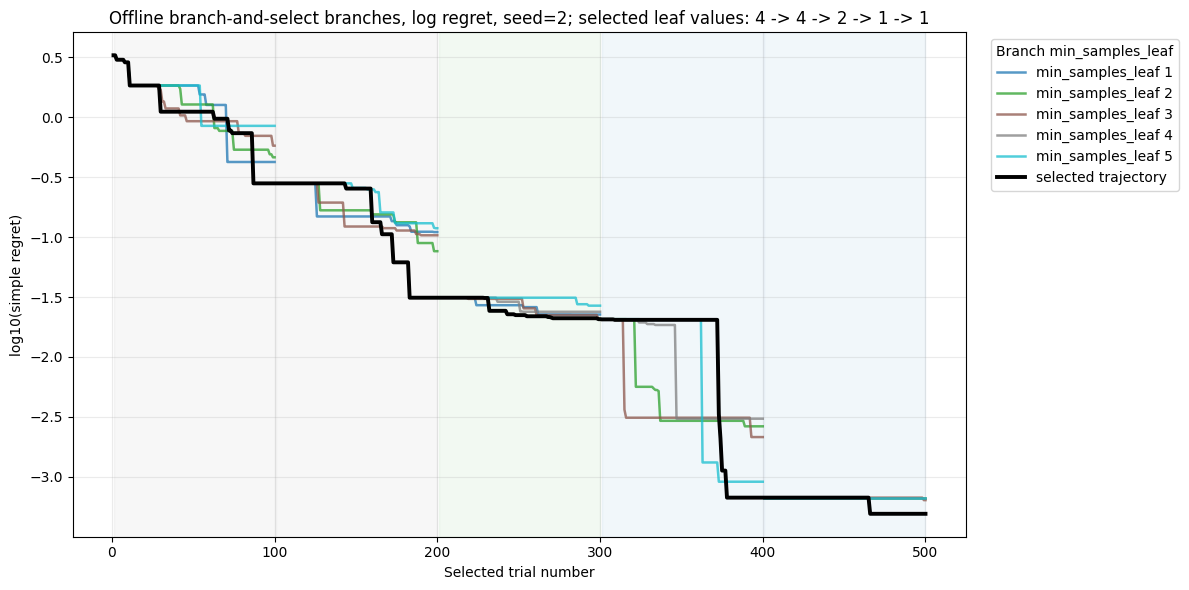

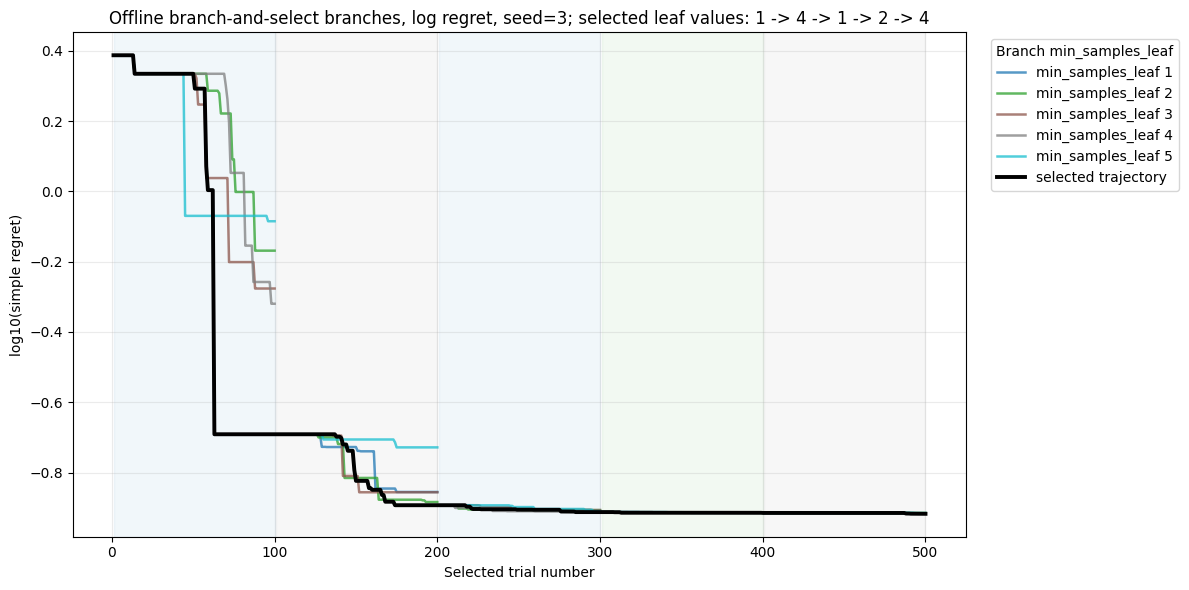

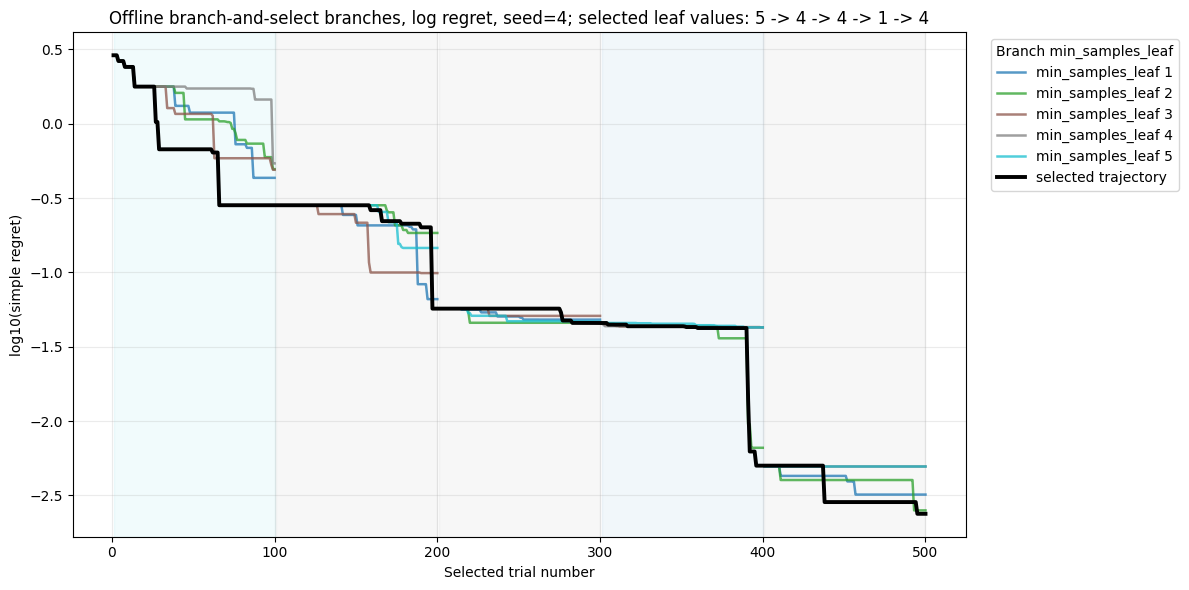

In [53]:
for seed in summary_df["seed"] if len(summary_df) else []:
    plot_branch_select_log_regret(seed=int(seed))
    plt.savefig(FIGURE_DIRECTORY / f"branch_select_log_regret_seed_{seed}.png", dpi=200)
    plt.show()

## 1c. Branch performance on log2 simple-regret scale

Same as above, but using `log2(simple regret)` instead of `log10(simple regret)`. This changes the numeric scale, not the ordering or improvement locations.

In [54]:
def plot_branch_select_log2_regret(seed: int = 0) -> None:
    summary_path = BRANCH_SELECT_DIRECTORY / f"seed_{seed}" / "summary.json"
    if not summary_path.exists():
        raise FileNotFoundError(f"Missing {summary_path}. Run run_branch_select_min_samples_leaf.py first.")

    with open(summary_path) as fh:
        summary = json.load(fh)

    colors = dict(zip(MIN_SAMPLES_LEAF_VALUES, plt.cm.tab10(np.linspace(0, 1, len(MIN_SAMPLES_LEAF_VALUES)))))

    plt.figure(figsize=(12, 6))
    for block in summary["blocks"]:
        start = block["start_trial"]
        end = block["end_trial"]

        for branch in block["branches"]:
            leaf = int(branch["min_samples_leaf"])
            runhistory = load_runhistory(Path(branch["branch_dir"]))
            best_costs = best_so_far(runhistory_costs_in_order(runhistory))[:end]
            trajectory = log2_simple_regret(best_costs)
            xs = np.arange(1, len(trajectory) + 1)

            label = f"min_samples_leaf {leaf}" if block["block"] == 1 else None
            plt.plot(
                xs[start - 1 : end],
                trajectory[start - 1 : end],
                color=colors[leaf],
                alpha=0.75,
                linewidth=1.8,
                label=label,
            )

        selected_leaf = int(block["selected"]["min_samples_leaf"])
        plt.axvspan(start, end, color=colors[selected_leaf], alpha=0.06)

    selected_best_costs = best_so_far(runhistory_costs_in_order(load_selected_runhistory(seed)))
    selected = log2_simple_regret(selected_best_costs)
    plt.plot(
        np.arange(1, len(selected) + 1),
        selected,
        color="black",
        linewidth=2.8,
        label="selected trajectory",
    )

    selected_leaf_values = " -> ".join(str(leaf) for leaf in summary["selected_leaf_values"])
    plt.title(f"Offline branch-and-select branches, log2 regret, seed={seed}; selected leaf values: {selected_leaf_values}")
    plt.xlabel("Selected trial number")
    plt.ylabel("log2(simple regret)")
    plt.legend(title="Branch min_samples_leaf", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()

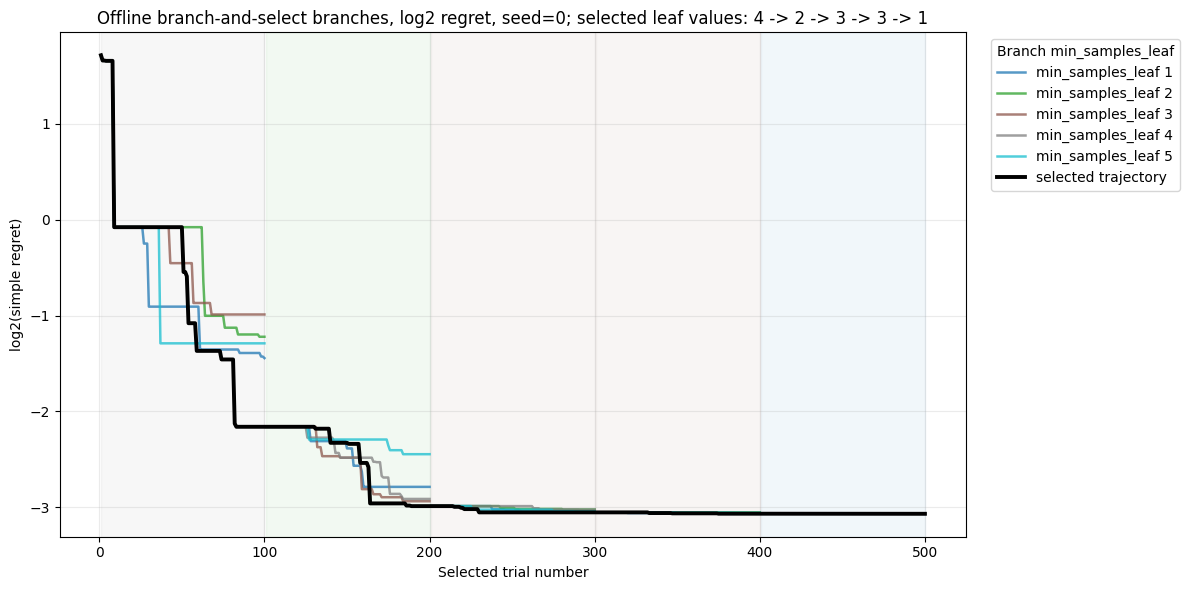

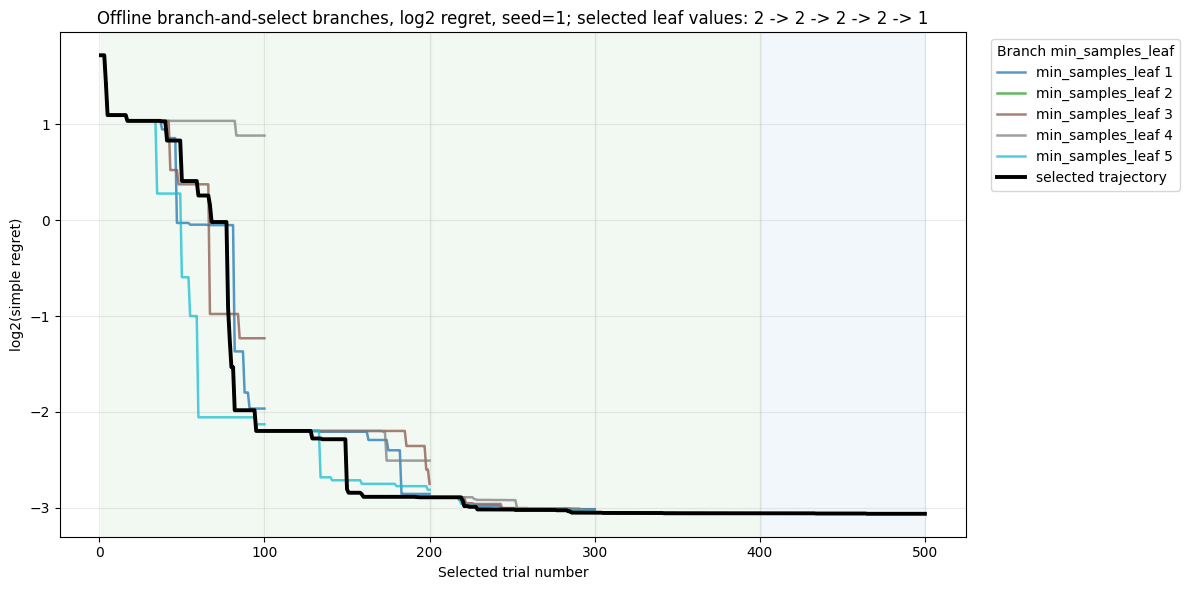

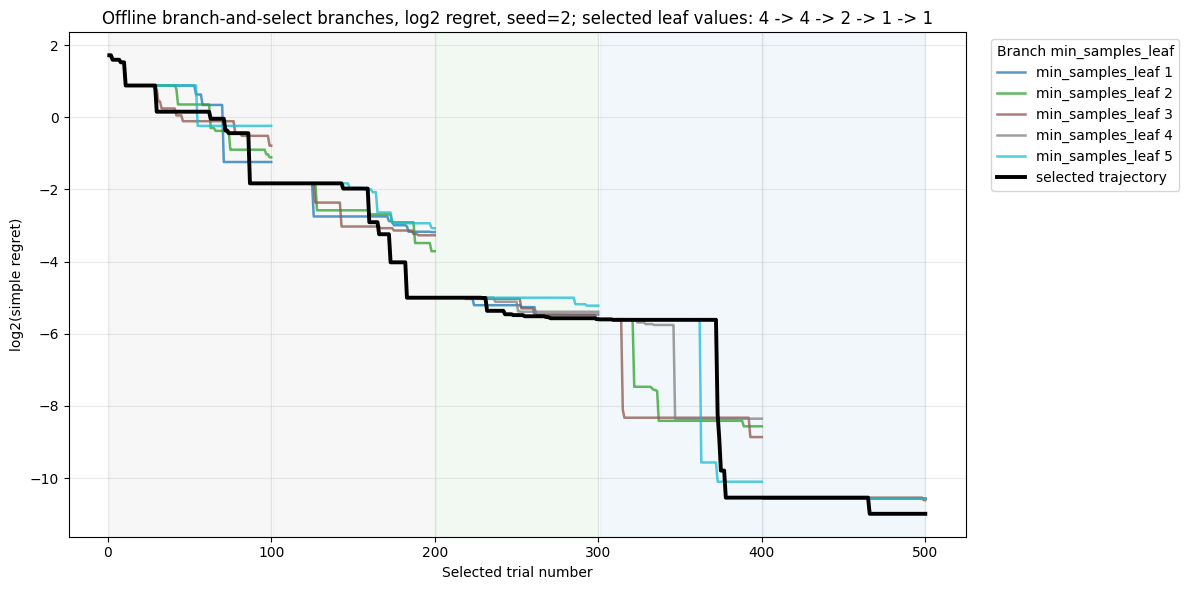

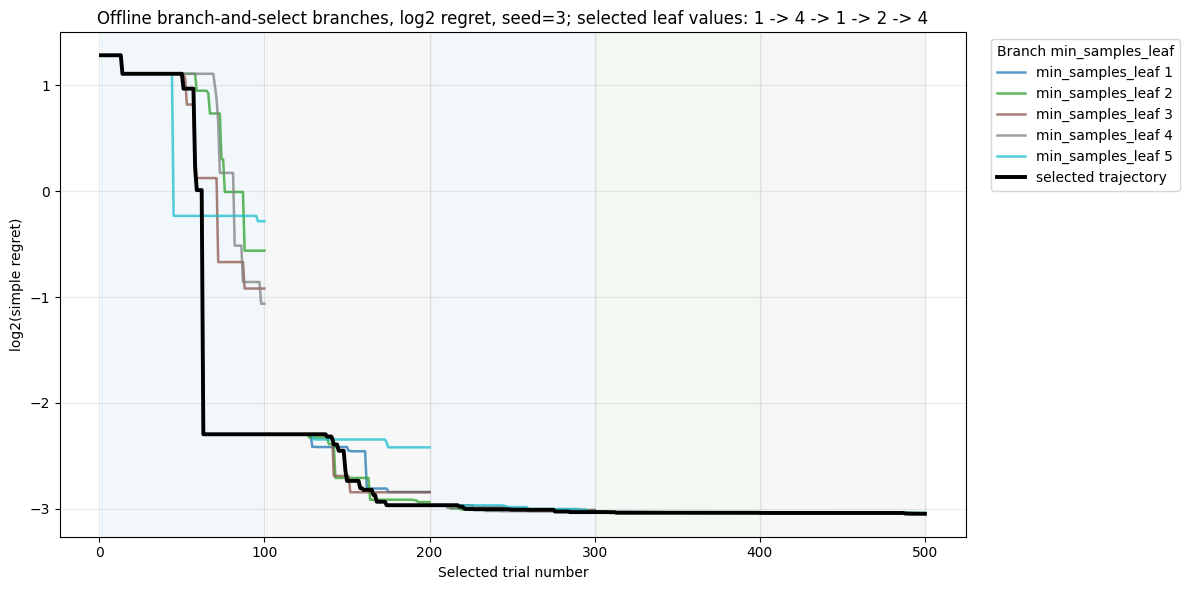

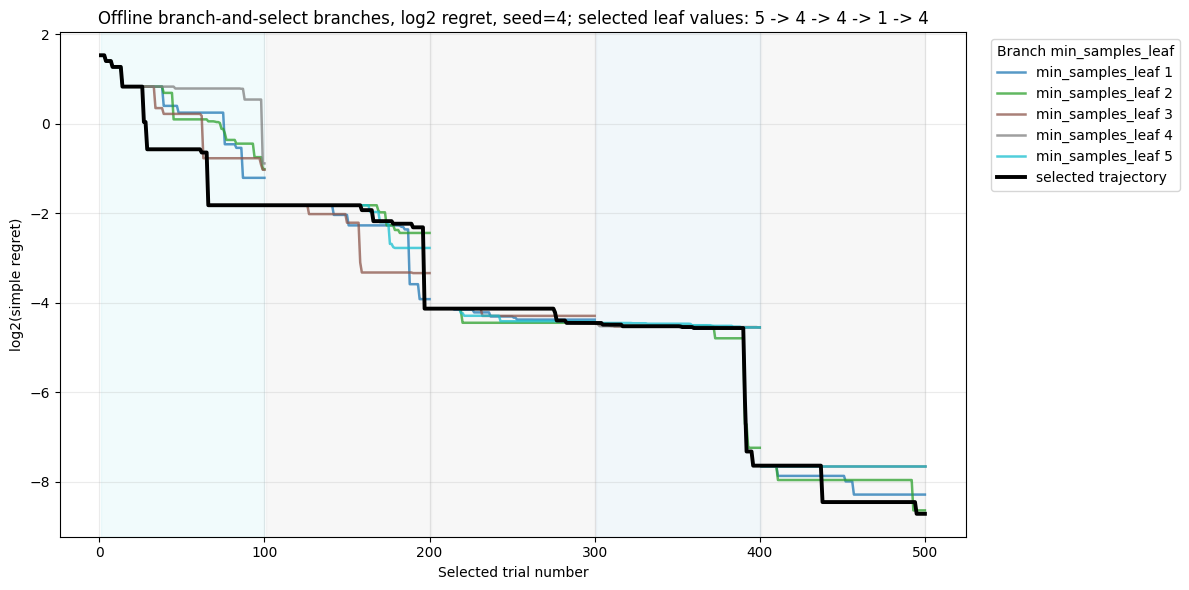

In [55]:
for seed in summary_df["seed"] if len(summary_df) else []:
    plot_branch_select_log2_regret(seed=int(seed))
    plt.savefig(FIGURE_DIRECTORY / f"branch_select_log2_regret_seed_{seed}.png", dpi=200)
    plt.show()

## 2. Fixed leaf values vs learned policy with confidence intervals

The confidence intervals are pointwise 95% Student-t intervals across seeds for the best incumbent cost so far.

In [56]:
def comparison_trajectories() -> dict[str, list[np.ndarray]]:
    trajectories: dict[str, list[np.ndarray]] = {policy: [] for policy in POLICIES}
    for policy in POLICIES:
        for seed in SEEDS:
            run_dir = COMPARISON_DIRECTORY / policy / str(seed)
            if not run_dir.exists():
                continue

            runhistory = load_runhistory(run_dir)
            trajectory = best_so_far(runhistory_costs_in_order(runhistory))
            if len(trajectory) >= N_TRIALS:
                trajectories[policy].append(trajectory[:N_TRIALS])

    return trajectories


trajectories = comparison_trajectories()
{policy: len(runs) for policy, runs in trajectories.items()}

{'leaf_1': 5,
 'leaf_2': 5,
 'leaf_3': 5,
 'leaf_4': 5,
 'leaf_5': 5,
 'learned_branch_select_policy': 5}

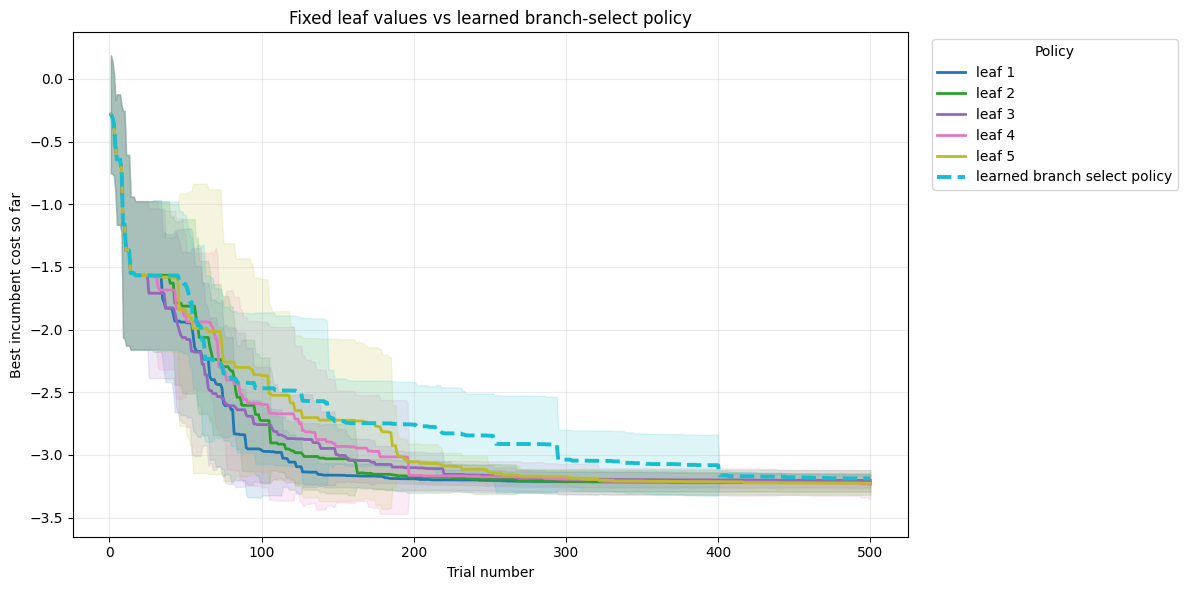

In [57]:
def plot_comparison_with_ci() -> None:
    xs = np.arange(1, N_TRIALS + 1)
    colors = dict(zip(POLICIES, plt.cm.tab10(np.linspace(0, 1, len(POLICIES)))))

    plt.figure(figsize=(12, 6))
    for policy, runs in trajectories.items():
        if not runs:
            continue

        values = np.vstack(runs)
        mean, lower, upper = mean_ci(values)
        label = policy.replace("_", " ")
        linewidth = 2.8 if policy == "learned_branch_select_policy" else 2.0
        linestyle = "--" if policy == "learned_branch_select_policy" else "-"

        plt.plot(xs, mean, label=label, color=colors[policy], linewidth=linewidth, linestyle=linestyle)
        plt.fill_between(xs, lower, upper, color=colors[policy], alpha=0.14)

    plt.title("Fixed leaf values vs learned branch-select policy")
    plt.xlabel("Trial number")
    plt.ylabel("Best incumbent cost so far")
    plt.legend(title="Policy", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()


plot_comparison_with_ci()
plt.savefig(FIGURE_DIRECTORY / "fixed_vs_learned_ci.png", dpi=200)
plt.show()

## 3. Final incumbent boxplots

/tmp/io632776/login23-4_183093/ipykernel_210581/1789084366.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(final_costs, labels=labels, showmeans=True)


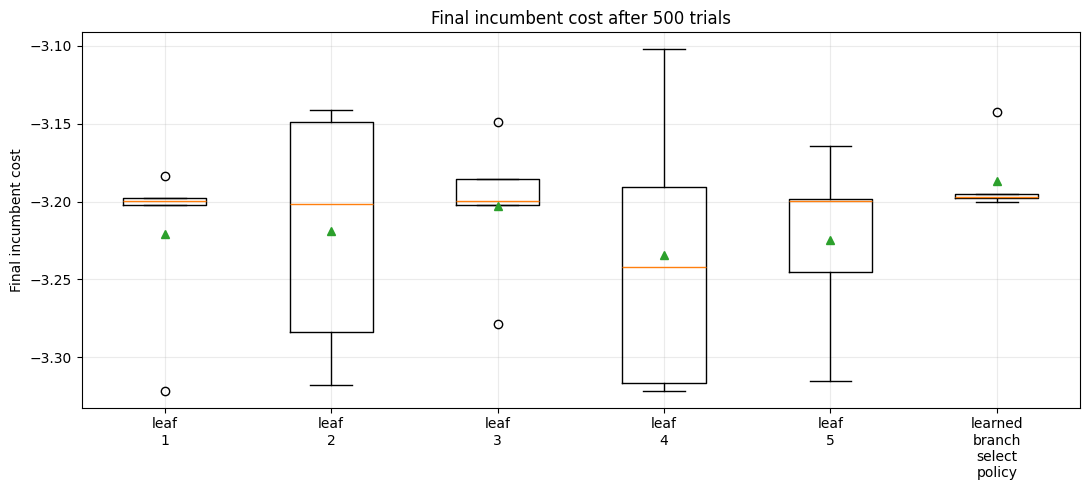

In [58]:
labels = []
final_costs = []

for policy in POLICIES:
    runs = trajectories.get(policy, [])
    if not runs:
        continue
    labels.append(policy.replace("_", "\n"))
    final_costs.append([float(run[-1]) for run in runs])

plt.figure(figsize=(11, 5))
plt.boxplot(final_costs, labels=labels, showmeans=True)
plt.title("Final incumbent cost after 500 trials")
plt.ylabel("Final incumbent cost")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(FIGURE_DIRECTORY / "fixed_vs_learned_final_boxplots.png", dpi=200)
plt.show()